In [1]:
import pandas as pd
df = pd.read_csv('players_fifa23.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'players_fifa23.csv'

In [6]:
df.head()

,ID,Name,FullName,Age,Height,Weight,PhotoUrl,Nationality,Overall,Potential,...,LMRating,CMRating,RMRating,LWBRating,CDMRating,RWBRating,LBRating,CBRating,RBRating,GKRating
0,158023,L. Messi,Lionel Messi,35,169,67,https://cdn.sofifa.net/players/158/023/23_60.png,Argentina,91,91,...,91,88,91,67,66,67,62,53,62,22
1,165153,K. Benzema,Karim Benzema,34,185,81,https://cdn.sofifa.net/players/165/153/23_60.png,France,91,91,...,89,84,89,67,67,67,63,58,63,21
2,188545,R. Lewandowski,Robert Lewandowski,33,185,81,https://cdn.sofifa.net/players/188/545/23_60.png,Poland,91,91,...,86,83,86,67,69,67,64,63,64,22
3,192985,K. De Bruyne,Kevin De Bruyne,31,181,70,https://cdn.sofifa.net/players/192/985/23_60.png,Belgium,91,91,...,91,91,91,82,82,82,78,72,78,24
4,231747,K. Mbappé,Kylian Mbappé,23,182,73,https://cdn.sofifa.net/players/231/747/23_60.png,France,91,95,...,92,84,92,70,66,70,66,57,66,21


In [7]:
df.columns

Index(['ID', 'Name', 'FullName', 'Age', 'Height', 'Weight', 'PhotoUrl',
       'Nationality', 'Overall', 'Potential', 'Growth', 'TotalStats',
       'BaseStats', 'Positions', 'BestPosition', 'Club', 'ValueEUR', 'WageEUR',
       'ReleaseClause', 'ClubPosition', 'ContractUntil', 'ClubNumber',
       'ClubJoined', 'OnLoad', 'NationalTeam', 'NationalPosition',
       'NationalNumber', 'PreferredFoot', 'IntReputation', 'WeakFoot',
       'SkillMoves', 'AttackingWorkRate', 'DefensiveWorkRate', 'PaceTotal',
       'ShootingTotal', 'PassingTotal', 'DribblingTotal', 'DefendingTotal',
       'PhysicalityTotal', 'Crossing', 'Finishing', 'HeadingAccuracy',
       'ShortPassing', 'Volleys', 'Dribbling', 'Curve', 'FKAccuracy',
       'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed', 'Agility',
       'Reactions', 'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength',
       'LongShots', 'Aggression', 'Interceptions', 'Positioning', 'Vision',
       'Penalties', 'Composure', 'Marking',

In [8]:
df.shape

(18539, 90)

In [9]:
col=['Name','Overall','Age','Nationality','Club','Positions','PaceTotal','ShootingTotal','PassingTotal','DribblingTotal','DefendingTotal','PhysicalityTotal']
df[col].isnull().sum()

Name                0
Overall             0
Age                 0
Nationality         0
Club                0
Positions           0
PaceTotal           0
ShootingTotal       0
PassingTotal        0
DribblingTotal      0
DefendingTotal      0
PhysicalityTotal    0
dtype: int64

In [10]:
top100=df.nlargest(100,'Overall')
top100.head()

,ID,Name,FullName,Age,Height,Weight,PhotoUrl,Nationality,Overall,Potential,...,LMRating,CMRating,RMRating,LWBRating,CDMRating,RWBRating,LBRating,CBRating,RBRating,GKRating
0,158023,L. Messi,Lionel Messi,35,169,67,https://cdn.sofifa.net/players/158/023/23_60.png,Argentina,91,91,...,91,88,91,67,66,67,62,53,62,22
1,165153,K. Benzema,Karim Benzema,34,185,81,https://cdn.sofifa.net/players/165/153/23_60.png,France,91,91,...,89,84,89,67,67,67,63,58,63,21
2,188545,R. Lewandowski,Robert Lewandowski,33,185,81,https://cdn.sofifa.net/players/188/545/23_60.png,Poland,91,91,...,86,83,86,67,69,67,64,63,64,22
3,192985,K. De Bruyne,Kevin De Bruyne,31,181,70,https://cdn.sofifa.net/players/192/985/23_60.png,Belgium,91,91,...,91,91,91,82,82,82,78,72,78,24
4,231747,K. Mbappé,Kylian Mbappé,23,182,73,https://cdn.sofifa.net/players/231/747/23_60.png,France,91,95,...,92,84,92,70,66,70,66,57,66,21


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


**## Ages distributions**


In this chart , we explore at what age footballers reach their peak performance

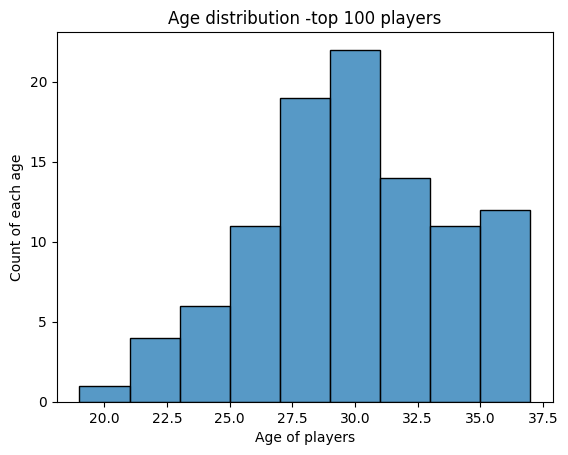

In [12]:
sns.histplot(top100['Age'])
plt.title('Age distribution -top 100 players')
plt.xlabel('Age of players')
plt.ylabel('Count of each age')
plt.show()

**## heat map for positions and there skills**

Here we analyze the key skills required for each position

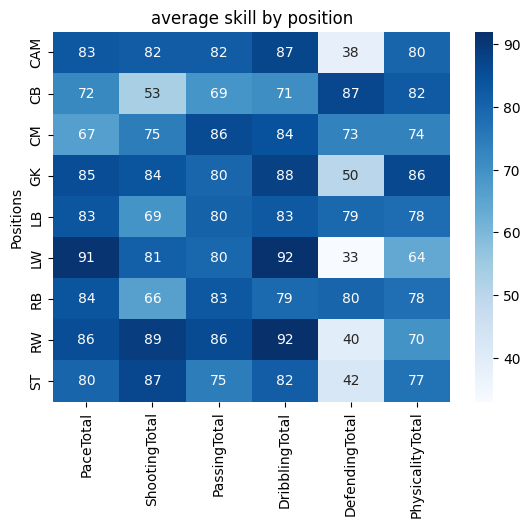

In [13]:
simple_positions=['GK','CB','LB','RB','CM','CMD','CAM','LW','RW','ST']
heatmap_data=top100[top100['Positions'].isin(simple_positions)].groupby('Positions')[['PaceTotal','ShootingTotal','PassingTotal','DribblingTotal','DefendingTotal','PhysicalityTotal']].mean()
sns.heatmap(heatmap_data,annot=True , fmt='.0f', cmap='Blues')
plt.title('average skill by position')
plt.show()

In [14]:
top100[['Height','Weight']].describe()

,Height,Weight
count,100.00000,100.000000
mean,182.62000,77.860000
std,7.57025,8.563512
min,165.00000,60.000000
25%,177.00000,71.000000
50%,183.00000,77.000000
75%,188.00000,84.000000
max,199.00000,99.000000


In [15]:
top100['BMI']=top100['Weight']/(top100['Height'])**2
top100.head(5)

,ID,Name,FullName,Age,Height,Weight,PhotoUrl,Nationality,Overall,Potential,...,CMRating,RMRating,LWBRating,CDMRating,RWBRating,LBRating,CBRating,RBRating,GKRating,BMI
0,158023,L. Messi,Lionel Messi,35,169,67,https://cdn.sofifa.net/players/158/023/23_60.png,Argentina,91,91,...,88,91,67,66,67,62,53,62,22,0.002346
1,165153,K. Benzema,Karim Benzema,34,185,81,https://cdn.sofifa.net/players/165/153/23_60.png,France,91,91,...,84,89,67,67,67,63,58,63,21,0.002367
2,188545,R. Lewandowski,Robert Lewandowski,33,185,81,https://cdn.sofifa.net/players/188/545/23_60.png,Poland,91,91,...,83,86,67,69,67,64,63,64,22,0.002367
3,192985,K. De Bruyne,Kevin De Bruyne,31,181,70,https://cdn.sofifa.net/players/192/985/23_60.png,Belgium,91,91,...,91,91,82,82,82,78,72,78,24,0.002137
4,231747,K. Mbappé,Kylian Mbappé,23,182,73,https://cdn.sofifa.net/players/231/747/23_60.png,France,91,95,...,84,92,70,66,70,66,57,66,21,0.002204


**### BMI and Overall correlation**

In this chart , we examine whether BMI has any correlation with a player's overall rating

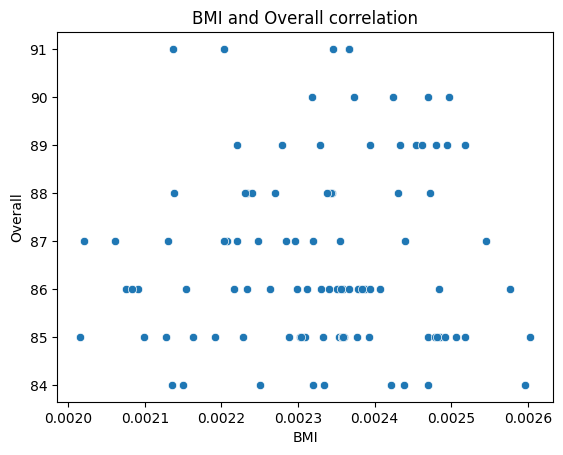

In [16]:
sns.scatterplot(data=top100,x='BMI',y='Overall')
plt.title('BMI and Overall correlation')
plt.show()

In [17]:
top100['BMI'].corr(top100['Overall'])

np.float64(0.03290152471079212)

**###Top 10 Nationalities - top 100 players**

Finally ,we explore which nationalities produce the most elite players

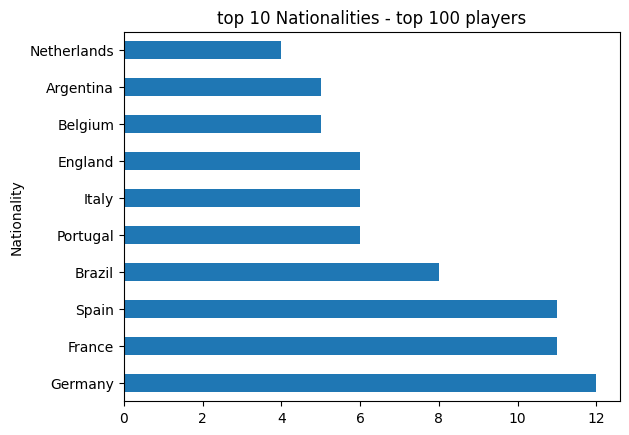

In [18]:
top100['Nationality'].value_counts().head(10).plot(kind='barh')
plt.title('top 10 Nationalities - top 100 players')
plt.show()

1. Top players tend to peak between the ages of 28 and 32.
2. Each position has a distinct set of key skills that define elite performance.
3. Countries with tactical playing styles produce the most elite players.
4. BMI shows no significant correlation with a player's overall rating.
In conclusion, becoming an elite footballer depends on mastering position-specific skills, playing within a strong tactical system, and reaching the right balance between experience and physical fitness 